STUDENT PERFORMANCE PREDICTION SYSTEM


DATASET INFORMATION

Dataset Shape:
(5000, 16)

First 5 Rows:
       student_id school_type school_location  gender parent_education  \
0  STU-2026-10001      Public           Urban    Male        Bachelors   
1  STU-2026-10002      Public           Urban    Male     Some College   
2  STU-2026-10003     Charter        Suburban    Male      High School   
3  STU-2026-10004      Public        Suburban    Male     Some College   
4  STU-2026-10005      Public           Rural  Female          Masters   

  internet_access extracurricular_activities tutoring_sessions  \
0             Yes                         No               Yes   
1             Yes                        Yes                No   
2             Yes                        Yes                No   
3             Yes                        Yes               Yes   
4             Yes                         No                No   

   study_hours_per_week  attendance_rate_pct  previous_gpa  \
0                  14.9           

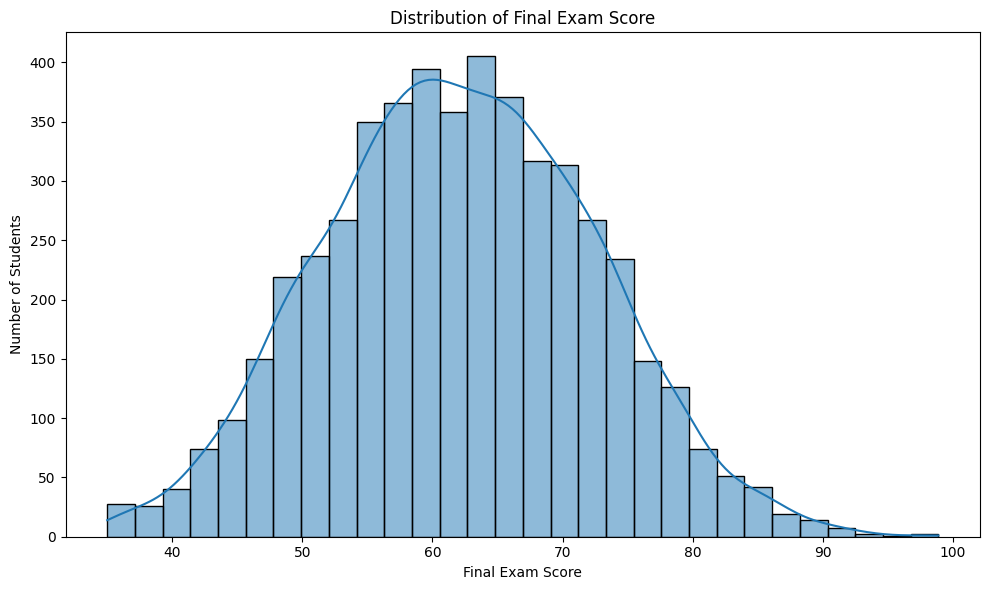

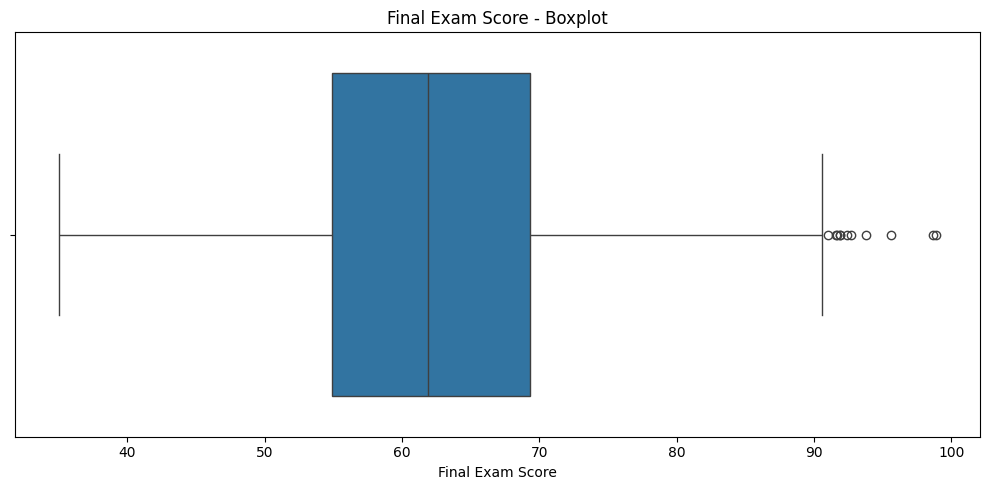

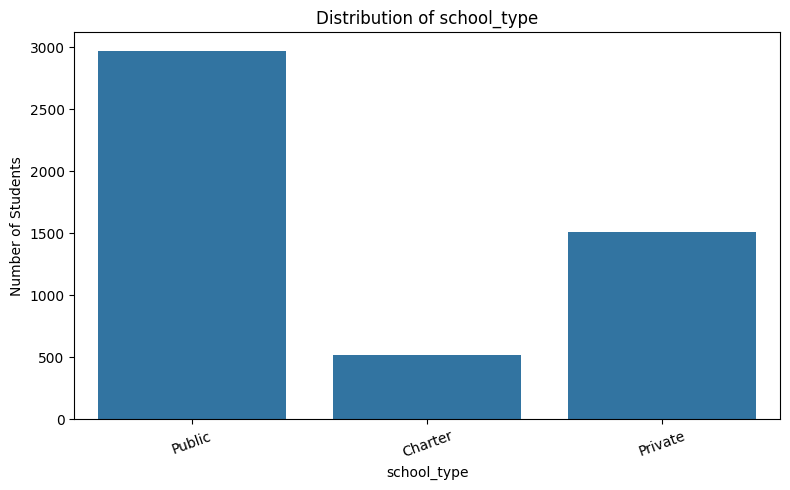

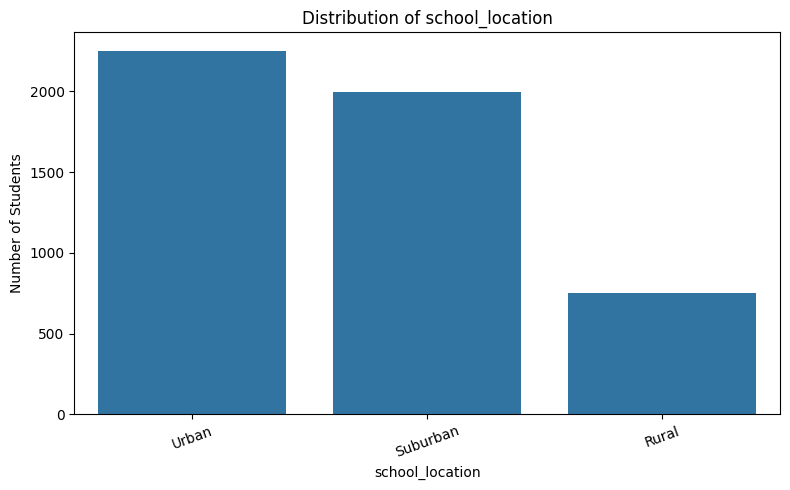

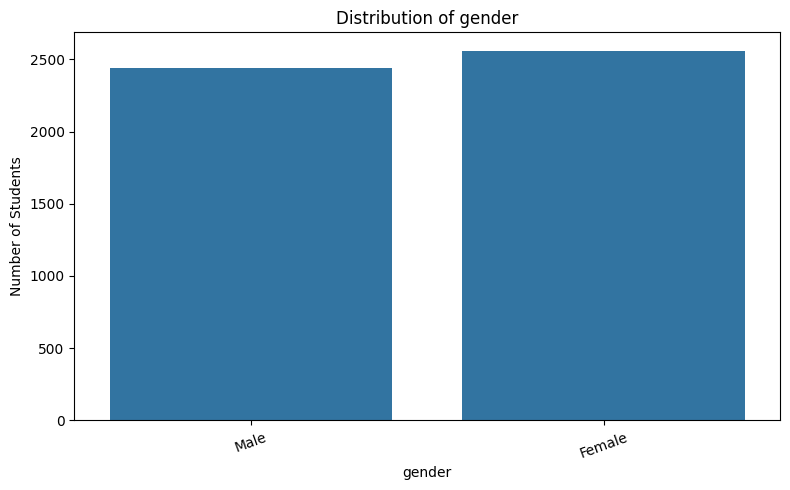

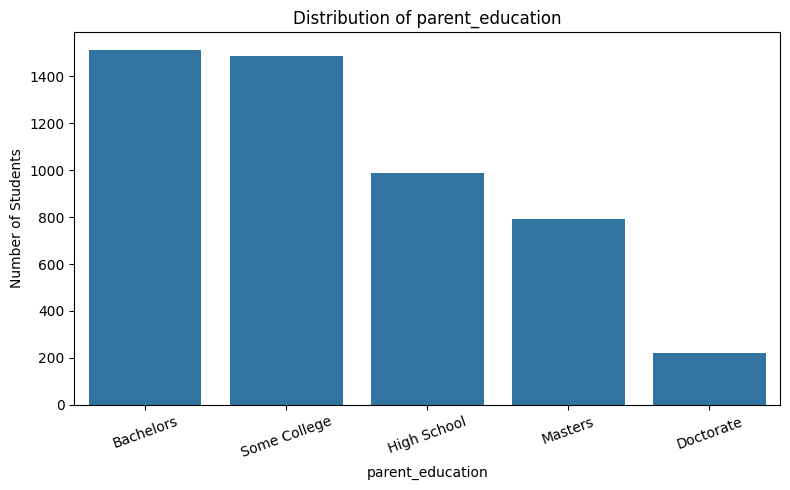

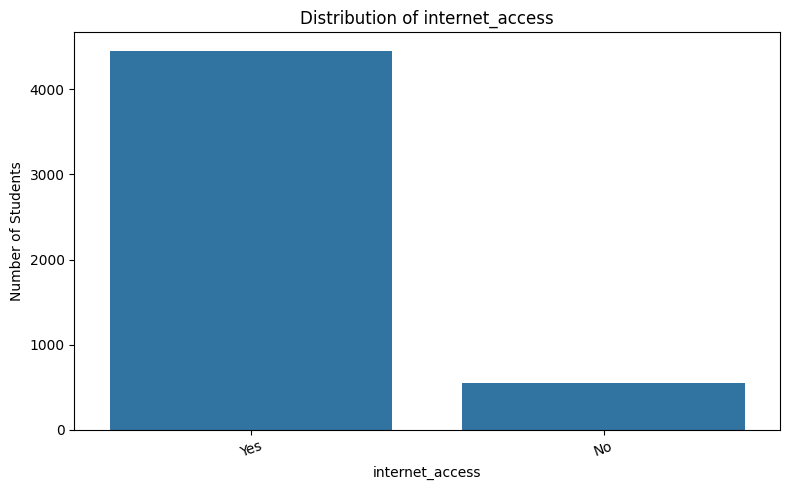

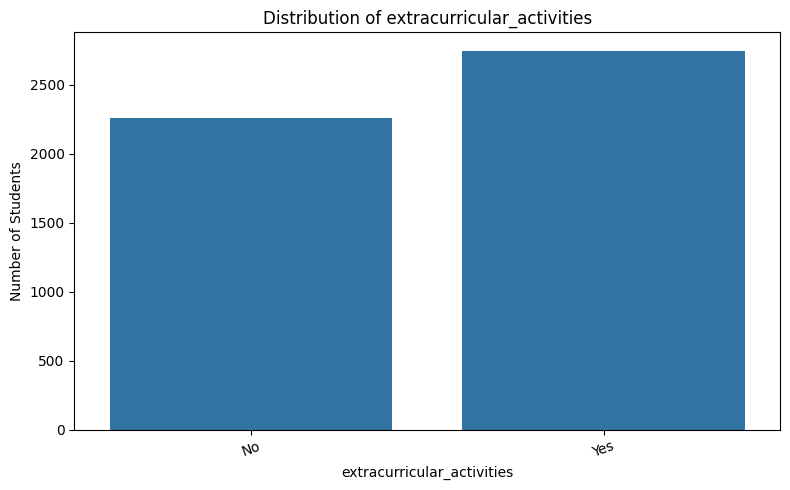

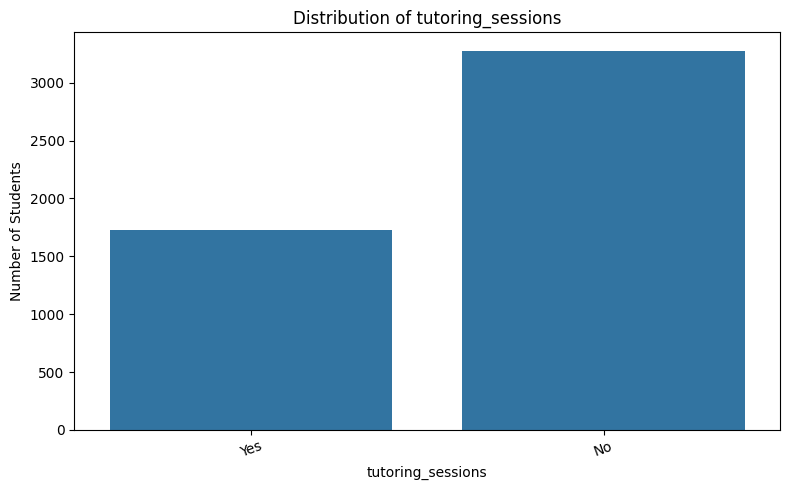

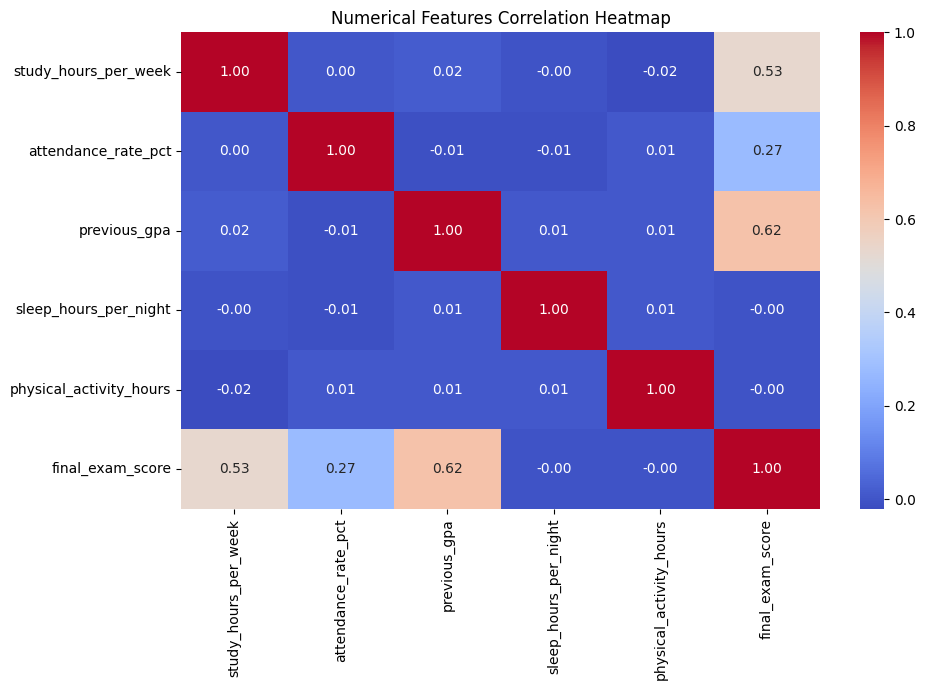

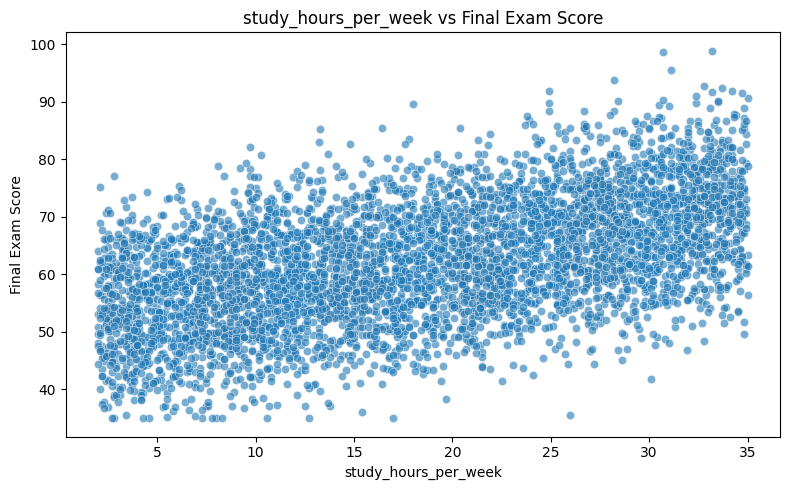

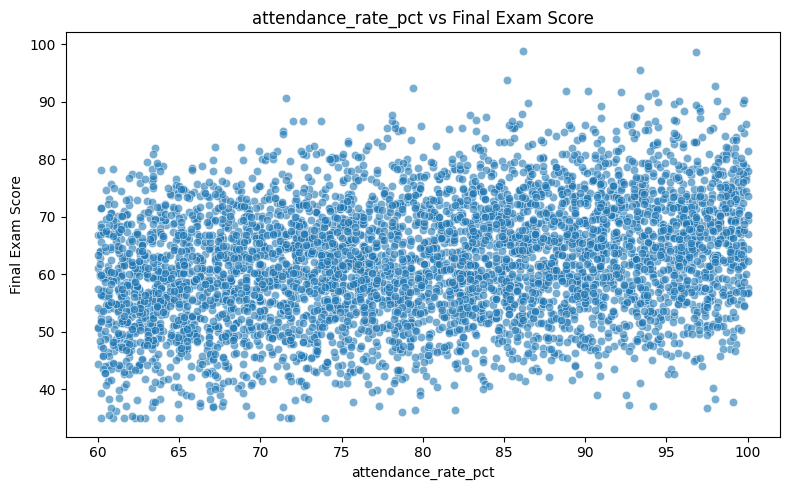

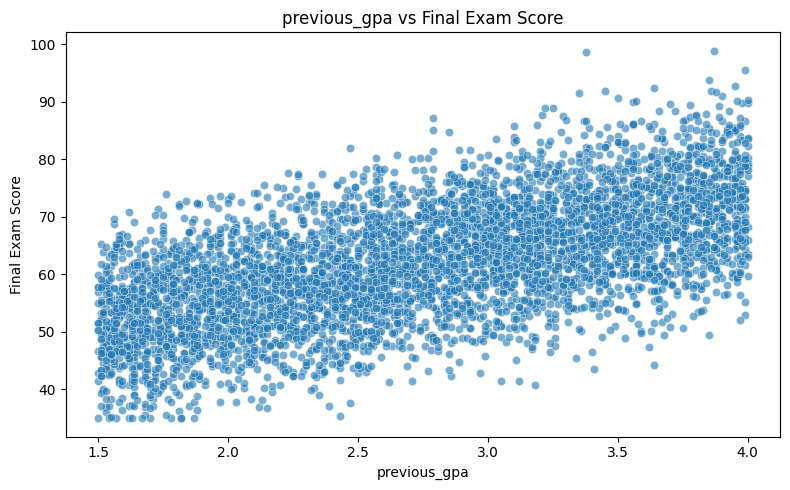

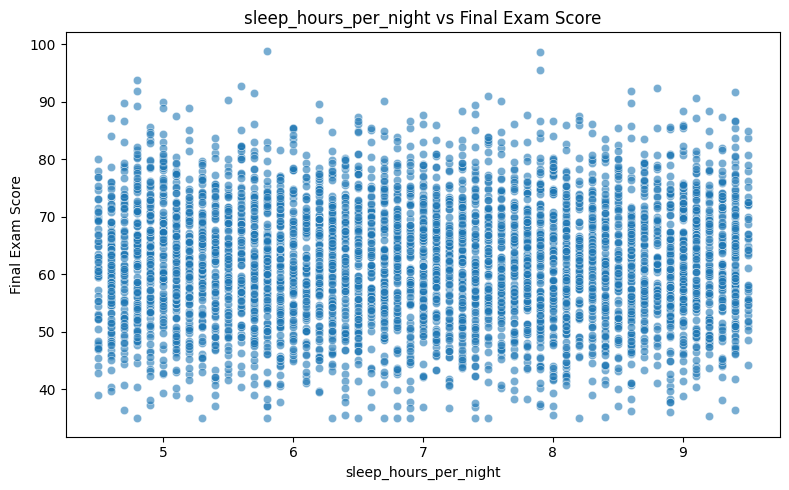

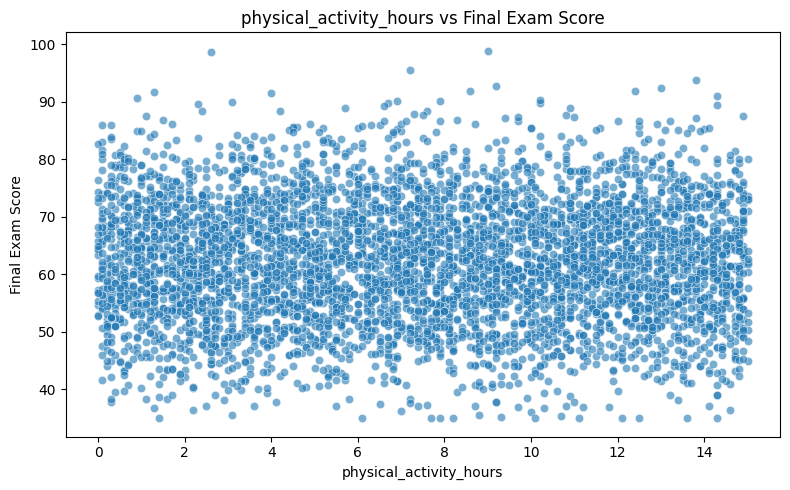


DATASET AFTER REMOVING LEAKAGE
  school_type school_location  gender parent_education internet_access  \
0      Public           Urban    Male        Bachelors             Yes   
1      Public           Urban    Male     Some College             Yes   
2     Charter        Suburban    Male      High School             Yes   
3      Public        Suburban    Male     Some College             Yes   
4      Public           Rural  Female          Masters             Yes   

  extracurricular_activities tutoring_sessions  study_hours_per_week  \
0                         No               Yes                  14.9   
1                        Yes                No                  18.8   
2                        Yes                No                  31.2   
3                        Yes               Yes                  29.4   
4                         No                No                  13.9   

   attendance_rate_pct  previous_gpa  sleep_hours_per_night  \
0                 67.9     

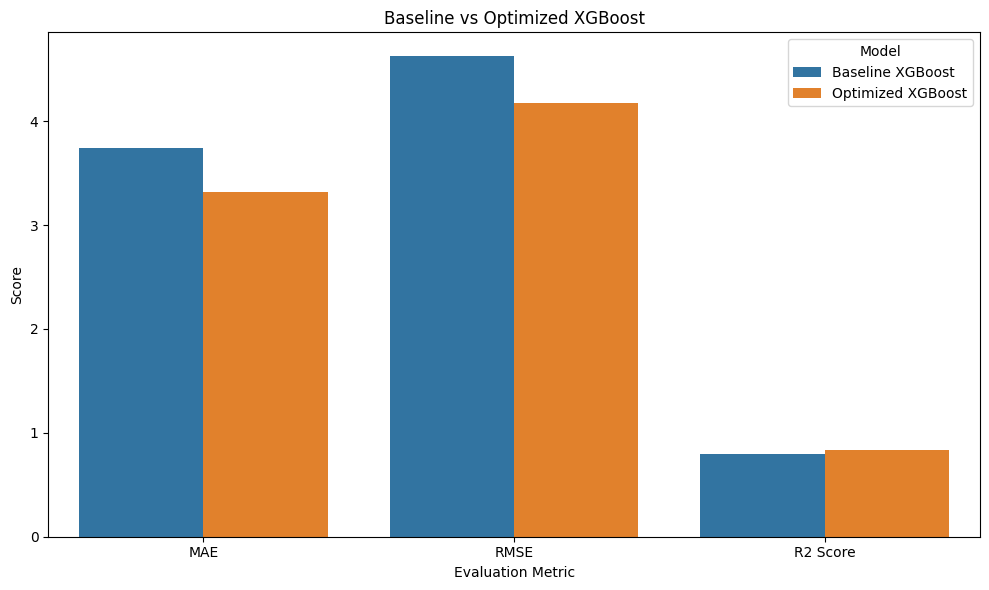

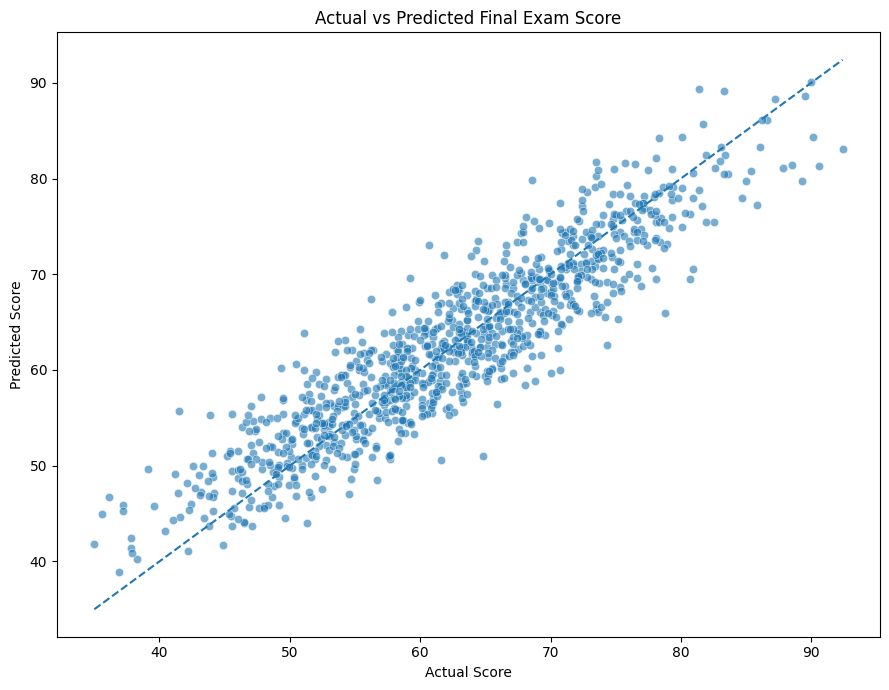

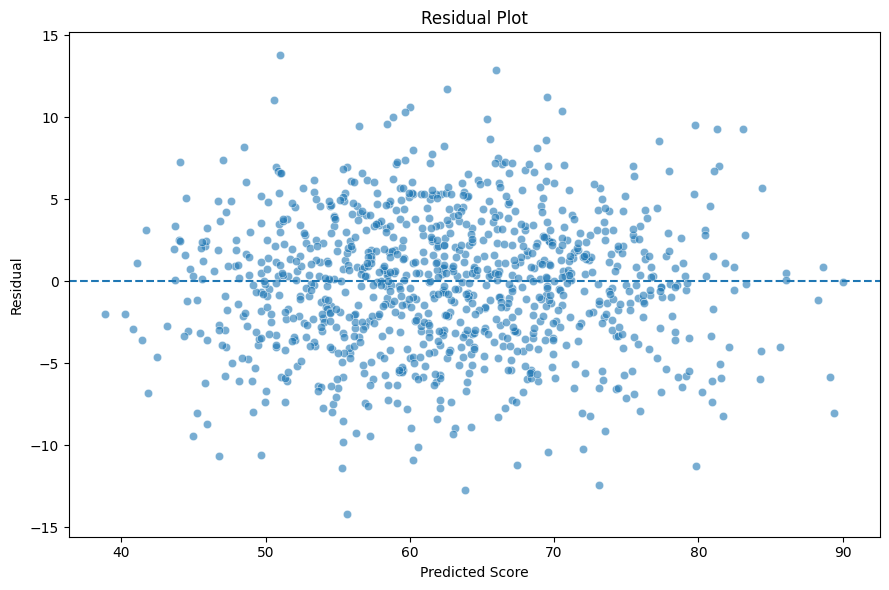

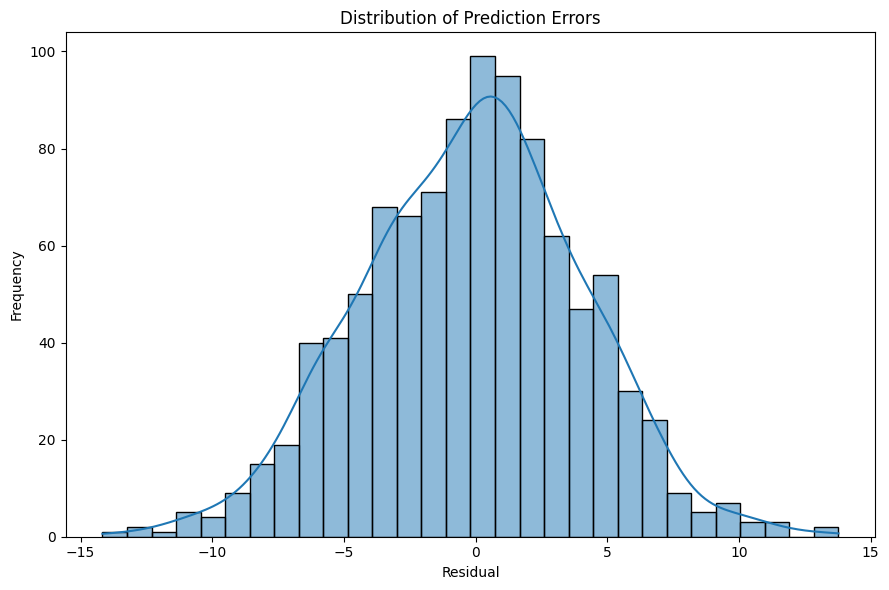


FEATURE IMPORTANCE
                       Feature  Importance
9                 previous_gpa    0.404716
7         study_hours_per_week    0.253677
6            tutoring_sessions    0.143625
8          attendance_rate_pct    0.083326
3             parent_education    0.049308
4              internet_access    0.036973
10       sleep_hours_per_night    0.005457
0                  school_type    0.005176
1              school_location    0.005135
11     physical_activity_hours    0.004910
5   extracurricular_activities    0.004632
2                       gender    0.003063


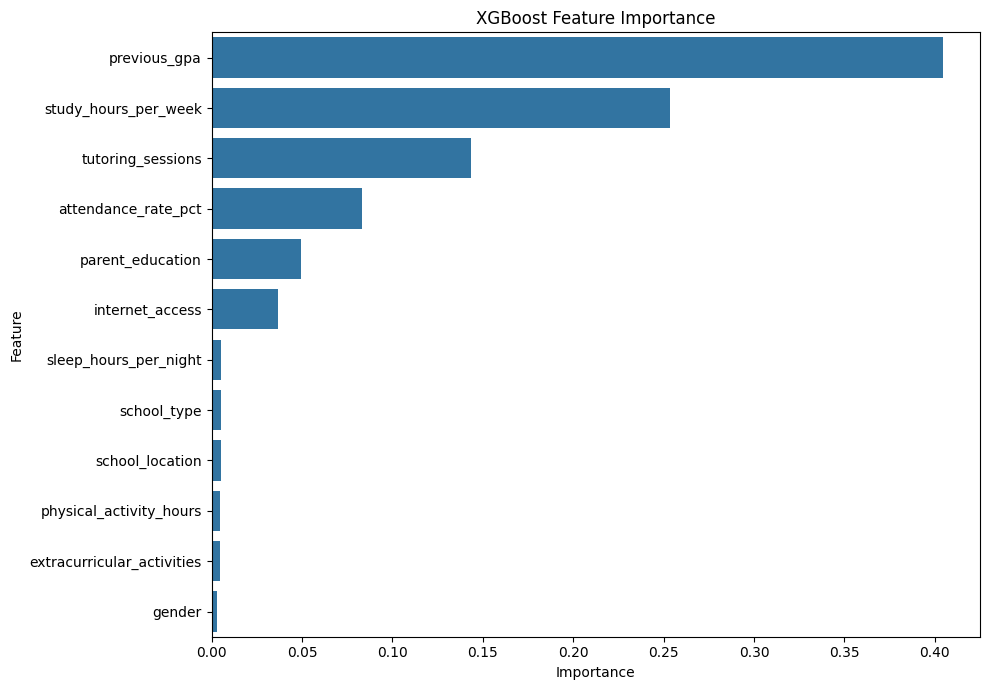


TOP 10 HYPERPARAMETER COMBINATIONS
    rank_test_score  mean_test_score  std_test_score  \
33                1        -4.101270        0.072539   
8                 2        -4.142944        0.065242   
17                3        -4.182816        0.077250   
11                4        -4.182887        0.062937   
1                 5        -4.201209        0.094995   
38                6        -4.249099        0.054128   
34                7        -4.249534        0.075834   
28                8        -4.256723        0.076360   
22                9        -4.273875        0.054075   
6                10        -4.298253        0.082081   

                                               params  
33  {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha...  
8   {'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha...  
17  {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha...  
11  {'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alp...  
1   {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha...  
38  {'subsa

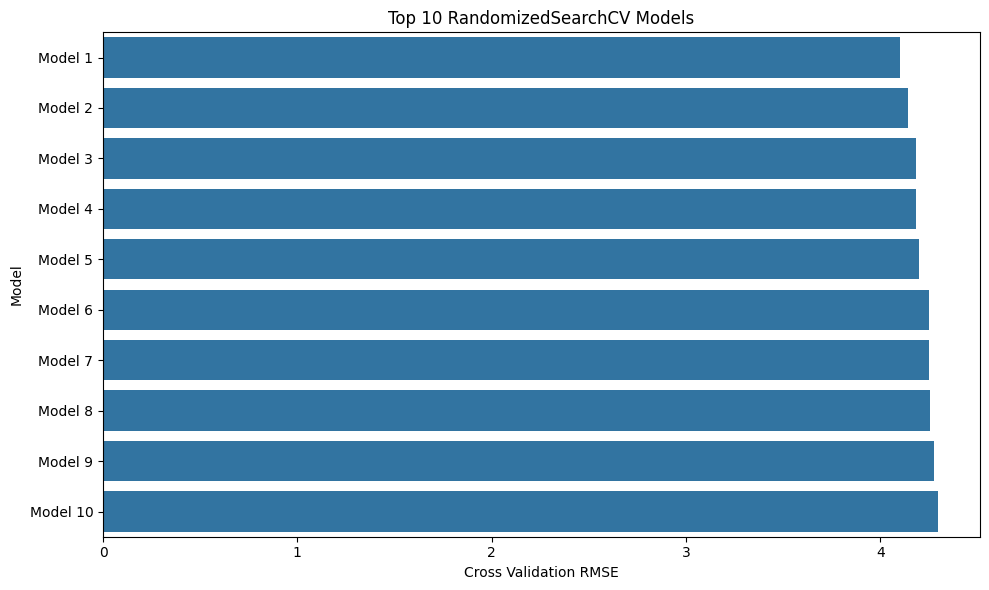


SAMPLE PREDICTIONS
    Actual Score  Predicted Score      Error  Absolute Error
0           77.9        78.038445  -0.138445        0.138445
1           65.3        66.235313  -0.935313        0.935313
2           58.4        59.756733  -1.356733        1.356733
3           58.3        52.607944   5.692056        5.692056
4           56.6        52.056046   4.543954        4.543954
5           68.4        66.034523   2.365477        2.365477
6           64.8        51.016811  13.783189       13.783189
7           59.1        63.700260  -4.600260        4.600260
8           90.6        81.293304   9.306696        9.306696
9           61.0        59.565174   1.434826        1.434826
10          64.6        62.368404   2.231596        2.231596
11          47.2        51.359943  -4.159943        4.159943
12          76.4        74.416489   1.983511        1.983511
13          72.4        77.099518  -4.699518        4.699518
14          50.5        54.624081  -4.124081        4.124081
15  

In [ ]:
# ============================================================
# STUDENT PERFORMANCE PREDICTION SYSTEM
# XGBOOST + RANDOMIZEDSEARCHCV
# ============================================================


# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

df = pd.read_csv("/content/student_performance_prediction_dataset.csv")

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# STEP 3: DATASET INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

print(df.dtypes)


print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(df.isnull().sum())


print("\n" + "=" * 60)
print("DUPLICATE VALUES")
print("=" * 60)

print("Duplicate Rows:", df.duplicated().sum())


# ============================================================
# STEP 4: REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)


# ============================================================
# STEP 5: STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

print(df.describe())


# ============================================================
# STEP 6: TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="final_exam_score",
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Final Exam Score"
)

plt.xlabel(
    "Final Exam Score"
)

plt.ylabel(
    "Number of Students"
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 7: BOXPLOT OF TARGET
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["final_exam_score"]
)

plt.title(
    "Final Exam Score - Boxplot"
)

plt.xlabel(
    "Final Exam Score"
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 8: NUMERICAL FEATURES
# ============================================================

numerical_features = [

    "study_hours_per_week",

    "attendance_rate_pct",

    "previous_gpa",

    "sleep_hours_per_night",

    "physical_activity_hours"

]


# ============================================================
# STEP 9: CATEGORICAL FEATURES
# ============================================================

categorical_features = [

    "school_type",

    "school_location",

    "gender",

    "parent_education",

    "internet_access",

    "extracurricular_activities",

    "tutoring_sessions"

]


# ============================================================
# STEP 10: CATEGORICAL FEATURE VISUALIZATION
# ============================================================

for column in categorical_features:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=column
    )

    plt.title(
        f"Distribution of {column}"
    )

    plt.xlabel(column)

    plt.ylabel(
        "Number of Students"
    )

    plt.xticks(
        rotation=20
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# STEP 11: CORRELATION HEATMAP
# ============================================================

correlation_columns = (
    numerical_features +
    ["final_exam_score"]
)

correlation = df[
    correlation_columns
].corr()


plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Numerical Features Correlation Heatmap"
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 12: FEATURE vs TARGET PLOTS
# ============================================================

for feature in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=feature,
        y="final_exam_score",
        alpha=0.6
    )

    plt.title(
        f"{feature} vs Final Exam Score"
    )

    plt.xlabel(feature)

    plt.ylabel(
        "Final Exam Score"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# STEP 13: REMOVE DATA LEAKAGE
# ============================================================

# student_id       -> Identifier only
# pass_fail        -> Derived from final score
# letter_grade     -> Derived from final score

leakage_columns = [

    "student_id",

    "pass_fail",

    "letter_grade"

]

df_model = df.drop(
    columns=leakage_columns
)


print("\n" + "=" * 60)
print("DATASET AFTER REMOVING LEAKAGE")
print("=" * 60)

print(df_model.head())


# ============================================================
# STEP 14: DEFINE FEATURES AND TARGET
# ============================================================

X = df_model.drop(
    columns=["final_exam_score"]
)

y = df_model[
    "final_exam_score"
]


print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("final_exam_score")


# ============================================================
# STEP 15: TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)


print("\n" + "=" * 60)
print("TRAIN TEST SPLIT")
print("=" * 60)

print(
    "Training Data:",
    X_train.shape
)

print(
    "Testing Data:",
    X_test.shape
)


# ============================================================
# STEP 16: LABEL ENCODING
# ============================================================

label_encoders = {}


for column in categorical_features:

    le = LabelEncoder()

    # Fit only on training data
    X_train[column] = le.fit_transform(
        X_train[column]
    )

    # Transform test data
    X_test[column] = le.transform(
        X_test[column]
    )

    label_encoders[column] = le


print("\n" + "=" * 60)
print("LABEL ENCODING COMPLETED")
print("=" * 60)

print(
    X_train[categorical_features].head()
)


# ============================================================
# STEP 17: STANDARD SCALING
# ============================================================

scaler = StandardScaler()


# Fit only on training data
X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)


# Transform test data
X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)


print("\n" + "=" * 60)
print("STANDARD SCALING COMPLETED")
print("=" * 60)

print(
    X_train[numerical_features].head()
)


# ============================================================
# STEP 18: BASELINE XGBOOST MODEL
# ============================================================

baseline_model = XGBRegressor(

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1

)


baseline_model.fit(
    X_train,
    y_train
)


# ============================================================
# STEP 19: BASELINE PREDICTION
# ============================================================

baseline_prediction = baseline_model.predict(
    X_test
)


# ============================================================
# STEP 20: BASELINE METRICS
# ============================================================

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)


baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)


baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)


print("\n" + "=" * 60)
print("BASELINE XGBOOST PERFORMANCE")
print("=" * 60)

print(
    f"MAE      : {baseline_mae:.4f}"
)

print(
    f"RMSE     : {baseline_rmse:.4f}"
)

print(
    f"R2 Score : {baseline_r2:.4f}"
)


# ============================================================
# STEP 21: XGBOOST MODEL FOR HYPERPARAMETER TUNING
# ============================================================

xgb_model = XGBRegressor(

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1

)


# ============================================================
# STEP 22: HYPERPARAMETER SEARCH SPACE
# ============================================================

param_grid = {

    "n_estimators": [
        100,
        200,
        300,
        500
    ],

    "max_depth": [
        2,
        3,
        4,
        5,
        6,
        8
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
        0.15,
        0.2
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "min_child_weight": [
        1,
        3,
        5,
        7
    ],

    "gamma": [
        0,
        0.1,
        0.2,
        0.3
    ],

    "reg_alpha": [
        0,
        0.01,
        0.1,
        1
    ],

    "reg_lambda": [
        1,
        1.5,
        2,
        5
    ]

}


# ============================================================
# STEP 23: RANDOMIZED SEARCH CV
# ============================================================

random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_grid,

    n_iter=40,

    scoring="neg_root_mean_squared_error",

    cv=5,

    random_state=42,

    n_jobs=-1,

    verbose=1,

    return_train_score=True

)


# ============================================================
# STEP 24: TRAIN RANDOMIZED SEARCH
# ============================================================

print("\n" + "=" * 60)
print("STARTING RANDOMIZED SEARCH")
print("=" * 60)

random_search.fit(
    X_train,
    y_train
)


# ============================================================
# STEP 25: BEST PARAMETERS
# ============================================================

best_parameters = random_search.best_params_


print("\n" + "=" * 60)
print("BEST PARAMETERS")
print("=" * 60)

for parameter, value in best_parameters.items():

    print(
        f"{parameter}: {value}"
    )


# ============================================================
# STEP 26: BEST CROSS VALIDATION SCORE
# ============================================================

best_cv_rmse = -random_search.best_score_


print("\nBest Cross Validation RMSE:")

print(
    round(best_cv_rmse, 4)
)


# ============================================================
# STEP 27: GET BEST MODEL
# ============================================================

best_model = random_search.best_estimator_


print("\n" + "=" * 60)
print("BEST XGBOOST MODEL")
print("=" * 60)

print(best_model)


# ============================================================
# STEP 28: FINAL TEST PREDICTION
# ============================================================

y_pred = best_model.predict(
    X_test
)


# ============================================================
# STEP 29: KEEP PREDICTIONS BETWEEN 0 AND 100
# ============================================================

y_pred = np.clip(
    y_pred,
    0,
    100
)


# ============================================================
# STEP 30: FINAL MODEL METRICS
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)


rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


r2 = r2_score(
    y_test,
    y_pred
)


print("\n" + "=" * 60)
print("FINAL OPTIMIZED XGBOOST PERFORMANCE")
print("=" * 60)

print(
    f"MAE      : {mae:.4f}"
)

print(
    f"RMSE     : {rmse:.4f}"
)

print(
    f"R2 Score : {r2:.4f}"
)


# ============================================================
# STEP 31: BASELINE VS OPTIMIZED MODEL
# ============================================================

model_comparison = pd.DataFrame({

    "Metric": [
        "MAE",
        "RMSE",
        "R2 Score"
    ],

    "Baseline XGBoost": [

        baseline_mae,

        baseline_rmse,

        baseline_r2

    ],

    "Optimized XGBoost": [

        mae,

        rmse,

        r2

    ]

})


print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(
    model_comparison
)


# ============================================================
# STEP 32: MODEL COMPARISON PLOT
# ============================================================

comparison_plot = model_comparison.melt(

    id_vars="Metric",

    var_name="Model",

    value_name="Score"

)


plt.figure(figsize=(10, 6))

sns.barplot(

    data=comparison_plot,

    x="Metric",

    y="Score",

    hue="Model"

)

plt.title(
    "Baseline vs Optimized XGBoost"
)

plt.xlabel(
    "Evaluation Metric"
)

plt.ylabel(
    "Score"
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 33: ACTUAL VS PREDICTED PLOT
# ============================================================

plt.figure(figsize=(9, 7))

sns.scatterplot(

    x=y_test,

    y=y_pred,

    alpha=0.6

)


# Perfect prediction line
plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    linestyle="--"

)


plt.title(
    "Actual vs Predicted Final Exam Score"
)

plt.xlabel(
    "Actual Score"
)

plt.ylabel(
    "Predicted Score"
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 34: RESIDUAL CALCULATION
# ============================================================

residuals = (
    y_test.values - y_pred
)


# ============================================================
# STEP 35: RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(

    x=y_pred,

    y=residuals,

    alpha=0.6

)


plt.axhline(

    y=0,

    linestyle="--"

)


plt.title(
    "Residual Plot"
)

plt.xlabel(
    "Predicted Score"
)

plt.ylabel(
    "Residual"
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 36: RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

sns.histplot(

    residuals,

    bins=30,

    kde=True

)


plt.title(
    "Distribution of Prediction Errors"
)

plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 37: FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_model.feature_importances_

})


feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)


print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

print(
    feature_importance
)


# ============================================================
# STEP 38: FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10, 7))

sns.barplot(

    data=feature_importance,

    x="Importance",

    y="Feature"

)

plt.title(
    "XGBoost Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 39: RANDOMIZED SEARCH TOP RESULTS
# ============================================================

cv_results = pd.DataFrame(
    random_search.cv_results_
)


cv_results = cv_results.sort_values(
    by="rank_test_score"
)


print("\n" + "=" * 60)
print("TOP 10 HYPERPARAMETER COMBINATIONS")
print("=" * 60)

print(

    cv_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "params"
        ]
    ].head(10)

)


# ============================================================
# STEP 40: TOP 10 MODELS PLOT
# ============================================================

top_models = cv_results.head(10).copy()


top_models["CV_RMSE"] = (
    -top_models["mean_test_score"]
)


top_models["Model"] = [

    f"Model {i + 1}"

    for i in range(
        len(top_models)
    )

]


plt.figure(figsize=(10, 6))

sns.barplot(

    data=top_models,

    x="CV_RMSE",

    y="Model"

)

plt.title(
    "Top 10 RandomizedSearchCV Models"
)

plt.xlabel(
    "Cross Validation RMSE"
)

plt.ylabel(
    "Model"
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 41: PREDICTION RESULT TABLE
# ============================================================

prediction_results = pd.DataFrame({

    "Actual Score": y_test.values,

    "Predicted Score": y_pred,

    "Error":
        y_test.values - y_pred,

    "Absolute Error":
        np.abs(
            y_test.values - y_pred
        )

})


print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

print(
    prediction_results.head(20)
)


# ============================================================
# STEP 42: SAVE PREDICTION RESULTS
# ============================================================

prediction_results.to_csv(

    "student_prediction_results.csv",

    index=False

)


print(
    "\nPrediction results saved as:"
)

print(
    "student_prediction_results.csv"
)


# ============================================================
# STEP 43: PERFORMANCE CLASSIFICATION FUNCTION
# ============================================================

def get_performance(score):

    # -----------------------------
    # PASS / FAIL
    # -----------------------------

    if score < 40:

        result = "FAIL"

    else:

        result = "PASS"


    # -----------------------------
    # PERFORMANCE LEVEL
    # -----------------------------

    if score < 40:

        performance = "Poor"

    elif score < 50:

        performance = "Average"

    elif score < 70:

        performance = "Good"

    elif score < 85:

        performance = "Very Good"

    else:

        performance = "Excellent"


    return result, performance


# ============================================================
# STEP 44: STUDENT PREDICTION FUNCTION
# ============================================================

def predict_student(

    student_data,

    model,

    encoders,

    scaler

):

    student_df = pd.DataFrame(
        [student_data]
    )


    # -----------------------------
    # LABEL ENCODING
    # -----------------------------

    for column in categorical_features:

        student_df[column] = encoders[
            column
        ].transform(
            student_df[column]
        )


    # -----------------------------
    # STANDARD SCALING
    # -----------------------------

    student_df[numerical_features] = scaler.transform(

        student_df[numerical_features]

    )


    # -----------------------------
    # XGBOOST PREDICTION
    # -----------------------------

    prediction = model.predict(
        student_df
    )[0]


    # -----------------------------
    # SCORE RANGE
    # -----------------------------

    prediction = np.clip(

        prediction,

        0,

        100

    )


    # -----------------------------
    # PASS / FAIL + PERFORMANCE
    # -----------------------------

    result, performance = get_performance(
        prediction
    )


    return (
        prediction,
        result,
        performance
    )


# ============================================================
# STEP 45: NEW STUDENT DATA
# ============================================================

new_student = {

    "school_type": "Public",

    "school_location": "Urban",

    "gender": "Male",

    "parent_education": "Bachelors",

    "internet_access": "Yes",

    "extracurricular_activities": "Yes",

    "tutoring_sessions": "Yes",

    "study_hours_per_week": 25,

    "attendance_rate_pct": 90,

    "previous_gpa": 3.2,

    "sleep_hours_per_night": 7,

    "physical_activity_hours": 5

}


# ============================================================
# STEP 46: PREDICT NEW STUDENT
# ============================================================

predicted_score, result, performance = predict_student(

    new_student,

    best_model,

    label_encoders,

    scaler

)


# ============================================================
# STEP 47: FINAL STUDENT RESULT
# ============================================================

print("\n")

print("=" * 60)
print("       STUDENT PERFORMANCE PREDICTION")
print("=" * 60)

print(
    f"Predicted Final Exam Score : {predicted_score:.2f}"
)

print(
    f"Result                     : {result}"
)

print(
    f"Performance Level          : {performance}"
)

print("=" * 60)


# ============================================================
# STEP 48: FINAL PROJECT SUMMARY
# ============================================================

print("\n")

print("=" * 60)
print("             PROJECT SUMMARY")
print("=" * 60)

print(
    "Algorithm          : XGBoost Regressor"
)

print(
    "Hyperparameter     : RandomizedSearchCV"
)

print(
    "Cross Validation   : 5-Fold CV"
)

print(
    f"MAE                : {mae:.4f}"
)

print(
    f"RMSE               : {rmse:.4f}"
)

print(
    f"R2 Score           : {r2:.4f}"
)

print(
    f"Predicted Score    : {predicted_score:.2f}"
)

print(
    f"Student Result     : {result}"
)

print(
    f"Performance        : {performance}"
)

print("=" * 60)